# NCR Voyix Practicum — Unsupervised Modeling Pipeline (A/C + optional B)
Builds an unsupervised similarity / clustering space using:
- **A)** Geospatial / network overlap features
- **C)** Scale / footprint features
- **B)** Operational / cost proxy features (optional; merge when available)

It supports:
- **V1:** scale + overlap segmentation
- **V2:** density-pattern segmentation (less size-driven)
- **V3:** pattern + operational burden (when B fields exist)

Outputs include cluster labels, cluster profiles, kNN-based imputation of B-fields for prospects, and validation.


## 0) Imports + paths
Update paths to point to your local copies (or keep defaults if running in this environment).


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt


In [2]:
# === INPUT FILES (edit these paths) ===
EXISTING_SITE_LEVEL_PATH = "/Users/jiatongpan/Downloads/ncr_existing_buffer_mapped_account.csv"

# Optional: if we exported the account-level overlap summary from Databricks
EXISTING_ACCOUNT_SUMMARY_PATH = None  # e.g. "target_account_overlap_summary_v_2.csv"

# B-fields table (account-level operational proxies) for EXISTING customers (to be provided by team)
# Must contain customer_name OR account_nbr + the requested B metrics
B_FIELDS_EXISTING_PATH = None  # e.g. "existing_account_operational_B_fields.csv"

# Prospects list (store counts) — optional for C; use if we need >150 store filtering
PROSPECT_STORE_COUNTS_PATH = "/Users/jiatongpan/Downloads/us_retail_store_counts.xlsx"

# If later we get prospects geo overlap features (A/C), export to csv and set:
PROSPECT_FEATURES_PATH = None  # e.g. "prospect_account_features_A_C.csv"


## 1) Build existing account-level A/C features (from site-level)
This aggregates site-level points to account level and creates overlap + footprint features.


In [3]:
df = pd.read_csv(EXISTING_SITE_LEVEL_PATH)

# Basic cleaning
df = df[df["account_nbr"].notna()].copy()

# Ensure numeric overlap columns (these are 'new target count near existing sites' from your Part A file)
for c in ["new_tgt_cnt_4mi", "new_tgt_cnt_3mi", "new_tgt_cnt_2mi"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    else:
        raise ValueError(f"Expected column missing: {c}")

# Ensure coordinates numeric
for c in ["latitude", "longitude"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")w
    else:
        raise ValueError(f"Expected column missing: {c}")

existing_A = (
    df.groupby("account_nbr", dropna=True)
      .agg(
          customer_name=("customer_name", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
          site_count=("account_site_nbr", "nunique"),
          state_count=("state", "nunique"),

          avg_tgt_4mi=("new_tgt_cnt_4mi", "mean"),
          avg_tgt_3mi=("new_tgt_cnt_3mi", "mean"),
          avg_tgt_2mi=("new_tgt_cnt_2mi", "mean"),

          med_tgt_4mi=("new_tgt_cnt_4mi", "median"),
          med_tgt_3mi=("new_tgt_cnt_3mi", "median"),
          med_tgt_2mi=("new_tgt_cnt_2mi", "median"),

          total_tgt_4mi=("new_tgt_cnt_4mi", "sum"),
          total_tgt_3mi=("new_tgt_cnt_3mi", "sum"),
          total_tgt_2mi=("new_tgt_cnt_2mi", "sum"),

          lat_std=("latitude", "std"),
          lon_std=("longitude", "std")
      )
      .reset_index()
)

existing_A["lat_std"] = existing_A["lat_std"].fillna(0)
existing_A["lon_std"] = existing_A["lon_std"].fillna(0)

# Normalized overlap intensity
existing_A["neighbors_per_site_4mi"] = existing_A["total_tgt_4mi"] / existing_A["site_count"].replace(0, np.nan)
existing_A["neighbors_per_site_3mi"] = existing_A["total_tgt_3mi"] / existing_A["site_count"].replace(0, np.nan)
existing_A["neighbors_per_site_2mi"] = existing_A["total_tgt_2mi"] / existing_A["site_count"].replace(0, np.nan)

# Log transforms to reduce scale dominance
existing_A["log_site_count"] = np.log1p(existing_A["site_count"])
existing_A["log_total_tgt_4mi"] = np.log1p(existing_A["total_tgt_4mi"])
existing_A["log_total_tgt_3mi"] = np.log1p(existing_A["total_tgt_3mi"])
existing_A["log_total_tgt_2mi"] = np.log1p(existing_A["total_tgt_2mi"])

existing_A.head()


,account_nbr,customer_name,site_count,state_count,avg_tgt_4mi,avg_tgt_3mi,avg_tgt_2mi,med_tgt_4mi,med_tgt_3mi,med_tgt_2mi,...,total_tgt_2mi,lat_std,lon_std,neighbors_per_site_4mi,neighbors_per_site_3mi,neighbors_per_site_2mi,log_site_count,log_total_tgt_4mi,log_total_tgt_3mi,log_total_tgt_2mi
0,10009370,Macy's,1,1,7.0,5.0,1.0,7.0,5.0,1.0,...,1.0,0.0,0.0,7.0,5.0,1.0,0.693147,2.079442,1.791759,0.693147
1,10011177,Macy's,1,1,28.0,18.0,3.0,28.0,18.0,3.0,...,3.0,0.0,0.0,28.0,18.0,3.0,0.693147,3.367296,2.944439,1.386294
2,100342,Family Dollar,1,1,18.0,7.0,1.0,18.0,7.0,1.0,...,1.0,0.0,0.0,18.0,7.0,1.0,0.693147,2.944439,2.079442,0.693147
3,10107516,Macy's,1,1,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.693147,0.693147,0.693147,0.693147
4,10110052,Walmart,1,1,4.0,2.0,0.0,4.0,2.0,0.0,...,0.0,0.0,0.0,4.0,2.0,0.0,0.693147,1.609438,1.098612,0.000000


## 2) Merge B-fields (operational proxies) when available
When we have 7 B-metrics for existing customers, merge them here.
We can join by `customer_name` or `account_nbr` depending on what the export includes.


In [4]:
existing = existing_A.copy()

if B_FIELDS_EXISTING_PATH is None:
    print("B_FIELDS_EXISTING_PATH is not set yet. Skipping B-fields merge for now.")
else:
    b = pd.read_csv(B_FIELDS_EXISTING_PATH)

    # Join by customer_name if present; otherwise by account_nbr
    if "customer_name" in b.columns:
        existing = existing.merge(b, on="customer_name", how="left")
    elif "account_nbr" in b.columns:
        existing = existing.merge(b, on="account_nbr", how="left")
    else:
        raise ValueError("B-fields file must contain either customer_name or account_nbr for joining.")

    print("Merged. Shape:", existing.shape)
    existing.head()


B_FIELDS_EXISTING_PATH is not set yet. Skipping B-fields merge for now.


## 3) Build the composite operational_burden_score (B8)
Higher score = more costly to serve.
We invert SLA met rate because higher SLA met implies lower burden.


In [5]:
def add_operational_burden_score(df):
    b_cols = [
        "incidents_per_site_year",
        "maintenance_hours_per_site_year",
        "median_minutes_to_complete",
        "sla_met_rate",  # inverted inside function
        "sco_incident_share",
        "pos_incident_share",
        "repaired_machines_per_site_year",
    ]
    missing = [c for c in b_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing B columns: {missing}")

    X = df[b_cols].copy()

    # Invert SLA met rate: higher SLA met => lower burden
    X["sla_met_rate"] = 1 - X["sla_met_rate"]

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    df = df.copy()
    df["operational_burden_score"] = np.nanmean(X_scaled, axis=1)
    return df

if B_FIELDS_EXISTING_PATH is not None:
    existing = add_operational_burden_score(existing)
    existing[["customer_name", "operational_burden_score"]].head()
else:
    print("Skipping operational_burden_score (B fields not merged yet).")


Skipping operational_burden_score (B fields not merged yet).


## 4) Define feature sets
- **V1**: footprint / scale segmentation (size + overlap)
- **V2**: density-pattern segmentation (pattern-focused)
- **V3**: V2 + operational burden (when B fields exist)


In [6]:
FEATURES_V1 = [
    # scale/footprint
    "log_site_count", "state_count",
    # overlap magnitude
    "log_total_tgt_4mi", "log_total_tgt_3mi", "log_total_tgt_2mi",
    # normalized intensity
    "neighbors_per_site_4mi", "neighbors_per_site_3mi", "neighbors_per_site_2mi",
    # geo spread proxy
    "lat_std", "lon_std",
]

FEATURES_V2 = [
    # density pattern (less size-driven)
    "avg_tgt_4mi", "avg_tgt_3mi", "avg_tgt_2mi",
    "med_tgt_4mi", "med_tgt_3mi", "med_tgt_2mi",
    "neighbors_per_site_4mi", "neighbors_per_site_3mi", "neighbors_per_site_2mi",
    "state_count",
    "lat_std", "lon_std",
]

FEATURES_B = [
    "incidents_per_site_year",
    "maintenance_hours_per_site_year",
    "median_minutes_to_complete",
    "sla_met_rate",
    "sco_incident_share",
    "pos_incident_share",
    "repaired_machines_per_site_year",
    "operational_burden_score",
]

FEATURES_V3 = FEATURES_V2 + FEATURES_B


## 5) Fit multiple unsupervised models and compare
We sweep **KMeans** and **GMM** over a range of k and report silhouette and Davies-Bouldin.
Use this to pick a reasonable number of clusters before interpreting results.


In [7]:
def fit_and_score_models(df, feature_cols, k_list=(2,3,4,5,6,7,8), random_state=42):
    X = df[feature_cols].copy()

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("pca", PCA(n_components=0.9, random_state=random_state))
    ])
    Xp = pipe.fit_transform(X)

    results = []

    for k in k_list:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = km.fit_predict(Xp)
        results.append(("kmeans", k, silhouette_score(Xp, labels), davies_bouldin_score(Xp, labels)))

    for k in k_list:
        gmm = GaussianMixture(n_components=k, random_state=random_state, covariance_type="full")
        labels = gmm.fit_predict(Xp)
        results.append(("gmm", k, silhouette_score(Xp, labels), davies_bouldin_score(Xp, labels)))

    res_df = pd.DataFrame(results, columns=["model", "k", "silhouette", "davies_bouldin"])
    return pipe, Xp, res_df.sort_values(["silhouette"], ascending=False)

pipe_v1, Xp_v1, scores_v1 = fit_and_score_models(existing, FEATURES_V1)
scores_v1.head(10)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


,model,k,silhouette,davies_bouldin
0,kmeans,2,0.887831,0.219958
1,kmeans,3,0.832770,0.429662
2,kmeans,4,0.780894,0.686361
3,kmeans,5,0.780022,0.677815
4,kmeans,6,0.774066,0.624541
5,kmeans,7,0.771801,0.645971
6,kmeans,8,0.766414,0.651787
12,gmm,7,0.503180,1.022830
7,gmm,2,0.500192,1.073624
9,gmm,4,0.497592,0.724198


## 6) Assign clusters + create cluster profiles
Pick a k from the score table (often 3–6 is interpretable) and generate summary profiles to interpret segments.


In [8]:
def assign_kmeans_clusters(df, feature_cols, k=4, random_state=42, prefix="v1"):
    X = df[feature_cols].copy()
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("pca", PCA(n_components=0.9, random_state=random_state))
    ])
    Xp = pipe.fit_transform(X)

    km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
    labels = km.fit_predict(Xp)

    out = df.copy()
    out[f"{prefix}_cluster"] = labels
    out[f"{prefix}_PC1"] = Xp[:, 0]
    out[f"{prefix}_PC2"] = Xp[:, 1] if Xp.shape[1] > 1 else 0
    return out, pipe, km

def cluster_profile(df, cluster_col, cols_to_summarize):
    prof = df.groupby(cluster_col)[cols_to_summarize].median().round(3)
    counts = df[cluster_col].value_counts().sort_index()
    return prof, counts

# Choose k (edit)
K_V1 = 4

existing_v1, pipe_v1, km_v1 = assign_kmeans_clusters(existing, FEATURES_V1, k=K_V1, prefix="v1")
prof_v1, counts_v1 = cluster_profile(existing_v1, "v1_cluster", FEATURES_V1)

print("Cluster sizes:")
display(counts_v1)
print("Cluster median profile:")
display(prof_v1)


Cluster sizes:


v1_cluster
0    453
1     13
2     60
3     42
Name: count, dtype: int64

Cluster median profile:


,log_site_count,state_count,log_total_tgt_4mi,log_total_tgt_3mi,log_total_tgt_2mi,neighbors_per_site_4mi,neighbors_per_site_3mi,neighbors_per_site_2mi,lat_std,lon_std
v1_cluster,,,,,,,,,,
0,0.693,1.0,2.485,2.079,1.386,8.333,5.750,3.000,0.000,0.000
1,6.892,46.0,9.593,9.182,8.650,10.764,6.993,3.855,4.898,14.172
2,1.609,3.0,4.270,3.749,3.157,9.717,6.191,3.446,2.576,5.390
3,1.792,4.0,4.190,3.663,3.157,12.417,8.778,4.650,4.640,16.912


### Quick visualization: PCA scatter of clusters (V1)


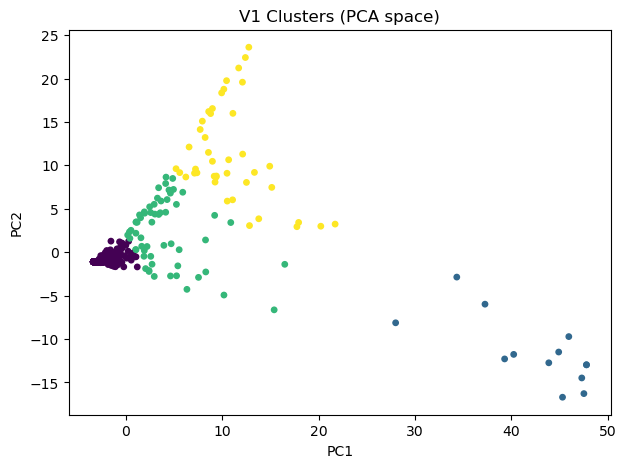

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(existing_v1["v1_PC1"], existing_v1["v1_PC2"], c=existing_v1["v1_cluster"], s=15)
plt.title("V1 Clusters (PCA space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## 7) Repeat for V2 (density pattern segmentation)
This view focuses on opportunity density patterns rather than raw footprint size.


In [10]:
pipe_v2, Xp_v2, scores_v2 = fit_and_score_models(existing, FEATURES_V2)
scores_v2.head(10)


,model,k,silhouette,davies_bouldin
0,kmeans,2,0.847905,0.245903
1,kmeans,3,0.723454,0.525815
2,kmeans,4,0.706266,0.552135
6,kmeans,8,0.523804,0.697088
5,kmeans,7,0.518756,0.707723
4,kmeans,6,0.497290,0.681814
3,kmeans,5,0.486104,0.605805
7,gmm,2,0.341183,1.427532
8,gmm,3,0.294720,1.414953
9,gmm,4,0.049098,1.939553


Cluster sizes (V2):


v2_cluster
0    476
1     13
2     16
3     63
Name: count, dtype: int64

Cluster median profile (V2):


,avg_tgt_4mi,avg_tgt_3mi,avg_tgt_2mi,med_tgt_4mi,med_tgt_3mi,med_tgt_2mi,neighbors_per_site_4mi,neighbors_per_site_3mi,neighbors_per_site_2mi,state_count,lat_std,lon_std
v2_cluster,,,,,,,,,,,,
0,8.000,5.500,3.000,8.0,5.0,3.0,8.000,5.500,3.000,1.0,0.000,0.000
1,10.764,6.993,3.855,9.0,5.0,3.0,10.764,6.993,3.855,46.0,4.898,14.172
2,46.500,36.500,20.000,46.5,36.5,20.0,46.500,36.500,20.000,1.0,0.000,0.000
3,12.111,7.815,4.000,9.0,6.0,3.0,12.111,7.815,4.000,4.0,4.618,14.242


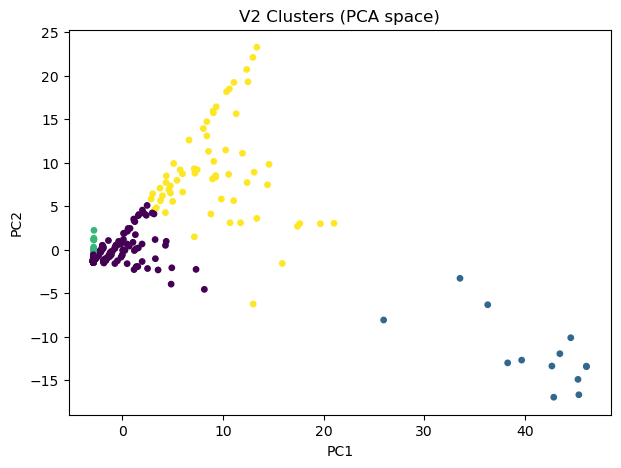

In [11]:
K_V2 = 4  # edit based on scores_v2

existing_v2, pipe_v2, km_v2 = assign_kmeans_clusters(existing, FEATURES_V2, k=K_V2, prefix="v2")
prof_v2, counts_v2 = cluster_profile(existing_v2, "v2_cluster", FEATURES_V2)

print("Cluster sizes (V2):")
display(counts_v2)
print("Cluster median profile (V2):")
display(prof_v2)

plt.figure(figsize=(7,5))
plt.scatter(existing_v2["v2_PC1"], existing_v2["v2_PC2"], c=existing_v2["v2_cluster"], s=15)
plt.title("V2 Clusters (PCA space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## 8) kNN similarity to impute B-fields for prospects/targets
Once we have A/C features for target accounts and B-fields for existing accounts, we can predict the missing operational proxies for targets using nearest neighbors.

We can use **euclidean** or **cosine** distance. Cosine often behaves better for 'pattern similarity'.


In [12]:
def knn_impute_operational(existing_df, target_df, feature_cols_for_similarity, b_cols, k=20, metric="euclidean"):
    # Shared preprocessing fit on existing
    X_exist = existing_df[feature_cols_for_similarity].copy()
    X_tgt   = target_df[feature_cols_for_similarity].copy()

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])
    X_exist_p = prep.fit_transform(X_exist)
    X_tgt_p   = prep.transform(X_tgt)

    nn = NearestNeighbors(n_neighbors=k, metric=metric)
    nn.fit(X_exist_p)
    dists, idx = nn.kneighbors(X_tgt_p)

    # Inverse-distance weights
    w = 1 / (dists + 1e-6)
    w = w / w.sum(axis=1, keepdims=True)

    preds = {}
    for col in b_cols:
        y = existing_df[col].values
        neigh_vals = y[idx]
        preds[col] = np.sum(neigh_vals * w, axis=1)

    out = target_df.reset_index(drop=True).copy()
    pred_df = pd.DataFrame(preds).add_prefix("pred_")
    return pd.concat([out, pred_df], axis=1)


### Validation: holdout test on existing
To defend results, we validate the imputation by pretending some existing accounts are 'targets' and comparing predicted vs true B-metrics.


In [13]:
def validate_knn_impute(existing_df, feature_cols, b_cols, test_size=0.25, k=20, metric="euclidean", random_state=42):
    df = existing_df.dropna(subset=b_cols).copy()
    train_df, test_df = train_test_split(df, test_size=test_size, random_state=random_state)

    scored = knn_impute_operational(
        existing_df=train_df,
        target_df=test_df,
        feature_cols_for_similarity=feature_cols,
        b_cols=b_cols,
        k=k,
        metric=metric
    )

    report = []
    for col in b_cols:
        y_true = test_df[col].values
        y_pred = scored[f"pred_{col}"].values
        report.append((col, mean_absolute_error(y_true, y_pred)))

    return pd.DataFrame(report, columns=["metric", "MAE"]).sort_values("MAE")

# Example (only works after B-fields merged):
# validate_knn_impute(existing, FEATURES_V2, FEATURES_B, k=20, metric="cosine")


## 9) Prospects: filtering and feature alignment


In [14]:
# Example: filter prospects by store count (if present in the Excel)
try:
    prospects = pd.read_excel(PROSPECT_STORE_COUNTS_PATH)
    print("Prospects columns:", prospects.columns.tolist()[:20])
except Exception as e:
    prospects = None
    print("Could not load prospects store count file:", e)

# If you know the store count column name, set it here:
STORE_COL = None  # e.g. "store_count" or "Stores" etc.

if prospects is not None and STORE_COL in (prospects.columns if prospects is not None else []):
    prospects_150 = prospects[prospects[STORE_COL] >= 150].copy()
    print("Prospects >=150:", len(prospects_150))
else:
    print("Set STORE_COL to the correct store count column name after inspecting the file.")


Prospects columns: ['store_name', 'store_count']
Set STORE_COL to the correct store count column name after inspecting the file.


## 10) Recommended deliverables to export
- Cluster labels for existing accounts (V1 + V2)
- Cluster profiles (median feature tables)
- For targets: predicted B-fields and operational_burden_score, plus nearest neighbors summary
- Validation report (MAE per B field)



In [ ]:
# Example exports
# existing_v1.to_csv("existing_v1_clusters.csv", index=False)
# existing_v2.to_csv("existing_v2_clusters.csv", index=False)
# prof_v1.to_csv("v1_cluster_profile.csv")
# prof_v2.to_csv("v2_cluster_profile.csv")
# validation_report.to_csv("knn_validation_mae.csv", index=False)
